In [347]:
# %% Block 1: Import packages and set global parameters
import numpy as np
from numpy.random import default_rng
from scipy.special import exp1
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# M101-like fiducial setup, calibrated to the observed star-forming main disc.
# M101 has an extended faint outer disc, but this notebook uses the brighter main disc
# where HII-region and spiral-arm measurements are better sampled.
R_in, R_out = 1.0, 14.4

# Diffusion parameters.  These control the KTZ smoothing scale,
# ell_K = sqrt(x0^2 + 4 kappa t), rather than direct observables.
kappa = 0.30         # kpc^2/Gyr
x0 = 0.10            # initial smoothing length (kpc)
t_star = 0.50        # maximum source age (Gyr)

# Spiral structure.  M101 is asymmetric and multi-armed; pitch angles vary by segment.
# A single logarithmic spiral is only a fiducial approximation.  Try 15, 20, and 25 deg.
m_arms = 3
pitch_angle = 20.0   # degree
pitch_rad = np.deg2rad(pitch_angle)
Theta0 = 0.0

# Arm modulation amplitude.
eta = 0.40
def h_func(Theta):
    return np.cos(Theta)

# Background rate $\lambda_0(\varpi) = \lambda_{00} \exp(-\varpi/h_R)$.
# h_R approx 4.8 kpc follows the main-disc boundary at roughly three scale lengths.
# lambda0_0 is an effective event rate; rescale it if one synthetic event represents
# a different stellar mass or yield unit.
lambda0_0 = 5.0e2   # kpc^-2 Gyr^-1
h_R = 4.8

# Source clustering.  The clustered component is a Thomas process:
# parent complexes are sampled from the same mean spiral-modulated rate,
# and child enrichment events are scattered around each parent.
enable_source_clustering = True
cluster_fraction = 0.50              # fraction of events drawn from clustered complexes
cluster_radius = 0.35                # kpc, one-sigma child offset around each parent
mean_children_per_cluster = 5.0      # mean child events per parent complex
cluster_theory_nodes = 24            # quadrature nodes for the C_NP age integral

# Output (fixed)
Y_val = 1.0

# Computational grid.
dx = 0.20
grid_radius = R_out + 1.0

# Number of independent numerical realizations used to estimate error bands.
# Increase this for publication-quality uncertainty estimates.
n_realizations = 10

rng = default_rng(42)
print("The settings have been configured.")

The settings have been configured.


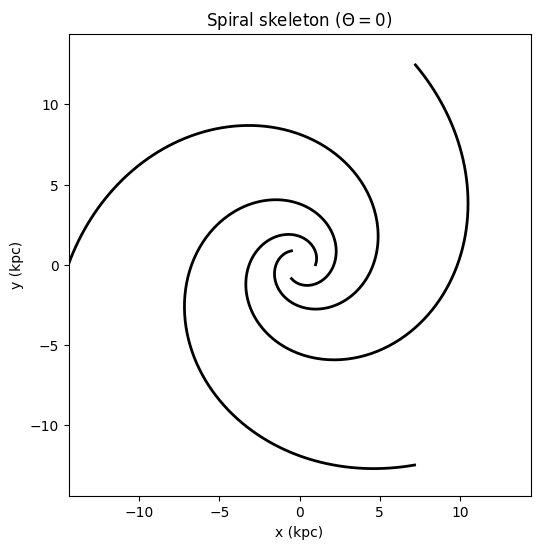

In [348]:
# %% Section 2: Definition of auxiliary functions (spiral phase, source rate, wavenumber)
def spiral_phase(varpi, phi):
    r"""The phase of a logarithmic spiral $\Theta$."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return Phi - m_arms * phi + Theta0

def lambda_rate(varpi, phi):
    r"""Non-uniform event rate $\lambda(\varpi,\phi)$."""
    lam0 = lambda0_0 * np.exp(-varpi / h_R)
    #lam0 = lambda0_0
    Theta = spiral_phase(varpi, phi)
    return lam0 * (1.0 + eta * h_func(Theta))

def k_perp(varpi):
    r"""Local arm-normal wavenumber $k_\perp$."""
    dPhi = (m_arms / np.tan(pitch_rad)) / varpi
    return np.sqrt(dPhi**2 + (m_arms / varpi)**2)

# Visualising a spiral pattern: draw the ridge line for $\Theta = 0$.
phi_plot = np.linspace(0, 2*np.pi, 500)
varpi_plot = np.linspace(R_in, R_out, 200)
fig, ax = plt.subplots(figsize=(6,6))
for k in range(m_arms):
    phi0 = (Theta0 + 2*np.pi*k) / m_arms
    # Solve Phi(varpi) - m*phi + Theta0 = 0 -> phi = (Phi(varpi) + Theta0 + 2*pi*k)/m
    phi_sp = ((m_arms / np.tan(pitch_rad)) * np.log(varpi_plot / R_in) + Theta0 + 2*np.pi*k) / m_arms
    ax.plot(varpi_plot * np.cos(phi_sp), varpi_plot * np.sin(phi_sp), 'k-', lw=2)
ax.set_xlim(-R_out, R_out)
ax.set_ylim(-R_out, R_out)
ax.set_aspect('equal')
ax.set_title(r'Spiral skeleton ($\Theta = 0$)')
ax.set_xlabel('x (kpc)'); ax.set_ylabel('y (kpc)')
plt.show()

Expected number of events: 28300, realization 1: 28442 (25688 clustered)


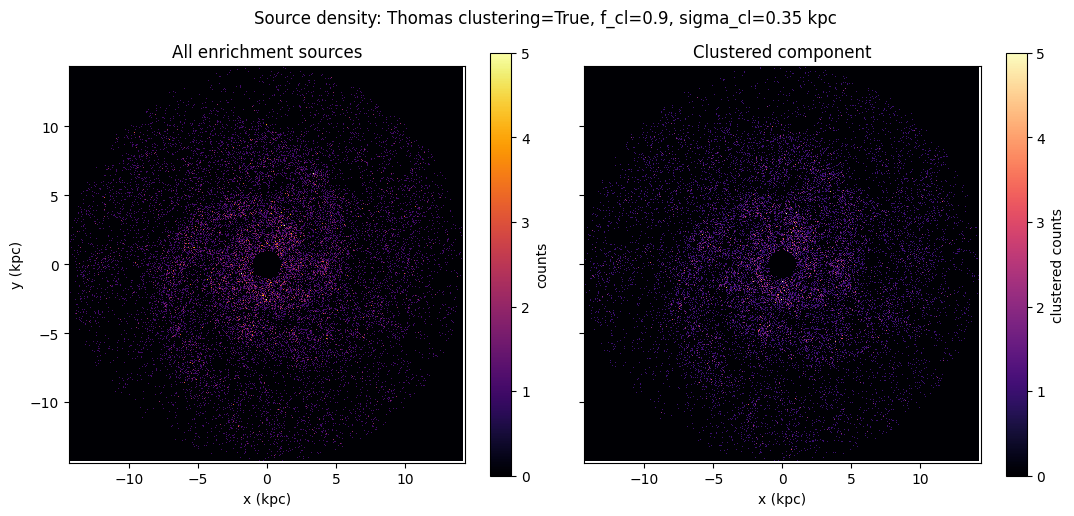

The displayed abundance field calculation has been completed.


In [349]:
# %% Block 3: Generating synthetic galaxies (inhomogeneous Poisson + clustered sources + Gaussian diffusion)
# --- Expected number of events ---
Nr, Nphi = 200, 400
varpi_edges = np.linspace(R_in, R_out, Nr+1)
phi_edges = np.linspace(0, 2*np.pi, Nphi+1)
varpi_c = 0.5*(varpi_edges[:-1] + varpi_edges[1:])
phi_c = 0.5*(phi_edges[:-1] + phi_edges[1:])
dvarpi = np.diff(varpi_edges)
dphi = 2*np.pi / Nphi
area_cells = (varpi_c * dvarpi)[:, None] * dphi
lam_grid = np.array([[lambda_rate(varpi_c[ir], phi_c[ip]) for ip in range(Nphi)] for ir in range(Nr)])
expected_total = np.sum(lam_grid * area_cells) * t_star
lam_max = np.max(lam_grid)

# --- Computational grid for abundance fields ---
grid_x = np.arange(-grid_radius, grid_radius+dx, dx)
grid_y = np.arange(-grid_radius, grid_radius+dx, dx)
X, Y = np.meshgrid(grid_x, grid_y)

def sample_spiral_positions(n_sample, rng):
    """Sample positions from the spiral-modulated mean rate in the annulus."""
    if n_sample <= 0:
        return np.empty(0), np.empty(0)

    events_varpi = np.empty(0)
    events_phi = np.empty(0)
    n_cand = max(int(3*n_sample), 1)
    while len(events_varpi) < n_sample:
        varpi_cand = np.sqrt(rng.uniform(R_in**2, R_out**2, n_cand))
        phi_cand = rng.uniform(0, 2*np.pi, n_cand)
        lam_cand = lambda_rate(varpi_cand, phi_cand)
        accept = rng.uniform(size=n_cand) < lam_cand / lam_max
        events_varpi = np.concatenate([events_varpi, varpi_cand[accept]])
        events_phi = np.concatenate([events_phi, phi_cand[accept]])
        n_cand = max(2*(n_sample - len(events_varpi)), 1)

    return events_varpi[:n_sample], events_phi[:n_sample]

def sample_clustered_positions(n_child_target, rng):
    """Sample Thomas-process child sources around spiral-modulated parent complexes."""
    if n_child_target <= 0:
        return np.empty(0), np.empty(0)

    child_x = np.empty(0)
    child_y = np.empty(0)
    mean_children = max(mean_children_per_cluster, 1.0e-6)

    while len(child_x) < n_child_target:
        deficit = n_child_target - len(child_x)
        n_parent = max(rng.poisson(deficit/mean_children), 1)
        parent_varpi, parent_phi = sample_spiral_positions(n_parent, rng)
        parent_x = parent_varpi*np.cos(parent_phi)
        parent_y = parent_varpi*np.sin(parent_phi)
        child_counts = rng.poisson(mean_children, n_parent)
        n_batch = int(np.sum(child_counts))
        if n_batch == 0:
            continue

        px = np.repeat(parent_x, child_counts)
        py = np.repeat(parent_y, child_counts)
        cx = px + rng.normal(0.0, cluster_radius, n_batch)
        cy = py + rng.normal(0.0, cluster_radius, n_batch)
        cr = np.hypot(cx, cy)
        keep = (cr >= R_in) & (cr <= R_out)
        child_x = np.concatenate([child_x, cx[keep]])
        child_y = np.concatenate([child_y, cy[keep]])

    return child_x[:n_child_target], child_y[:n_child_target]

def generate_synthetic_galaxy(rng, return_events=False):
    """Generate one enrichment realization with optional Thomas source clustering."""
    n_total = rng.poisson(expected_total)
    use_clustering = enable_source_clustering and cluster_fraction > 0
    if use_clustering:
        n_clustered = rng.binomial(n_total, np.clip(cluster_fraction, 0.0, 1.0))
    else:
        n_clustered = 0
    n_poisson = n_total - n_clustered

    poisson_varpi, poisson_phi = sample_spiral_positions(n_poisson, rng)
    poisson_x = poisson_varpi*np.cos(poisson_phi)
    poisson_y = poisson_varpi*np.sin(poisson_phi)
    cluster_x, cluster_y = sample_clustered_positions(n_clustered, rng)

    event_x = np.concatenate([poisson_x, cluster_x])
    event_y = np.concatenate([poisson_y, cluster_y])
    event_is_clustered = np.concatenate([
        np.zeros(len(poisson_x), dtype=bool),
        np.ones(len(cluster_x), dtype=bool),
    ])

    if len(event_x) > 0:
        order = rng.permutation(len(event_x))
        event_x = event_x[order]
        event_y = event_y[order]
        event_is_clustered = event_is_clustered[order]
    ages = rng.uniform(0, t_star, len(event_x))

    Z = np.zeros_like(X)
    for i in range(len(event_x)):
        Bs = 0.5*x0**2 + kappa * ages[i]
        cutoff = 5.0 * np.sqrt(2*Bs)
        dist2 = (X - event_x[i])**2 + (Y - event_y[i])**2
        mask = dist2 < cutoff**2
        Z[mask] += Y_val * np.exp(-dist2[mask]/(4*Bs)) / (4*np.pi*Bs)

    if return_events:
        return Z, len(event_x), event_x, event_y, event_is_clustered
    return Z, len(event_x)

# Generate one displayed realization. Additional independent realizations are
# generated below when estimating correlation-function error bands.
Z, N_events, event_x, event_y, event_is_clustered = generate_synthetic_galaxy(rng, return_events=True)
print(
    f"Expected number of events: {expected_total:.0f}, realization 1: {N_events} "
    f"({np.sum(event_is_clustered)} clustered)"
)

# Visualisation of event distribution for the displayed realization.
bins = 500
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
h0 = axes[0].hist2d(event_x, event_y, bins=bins, cmap='inferno')
plt.colorbar(h0[3], ax=axes[0], label='counts')
axes[0].set_title('All enrichment sources')
if np.any(event_is_clustered):
    h1 = axes[1].hist2d(event_x[event_is_clustered], event_y[event_is_clustered], bins=bins, cmap='magma')
    plt.colorbar(h1[3], ax=axes[1], label='clustered counts')
else:
    axes[1].text(0.5, 0.5, 'clustering disabled', transform=axes[1].transAxes,
                 ha='center', va='center')
axes[1].set_title('Clustered component')
for ax in axes:
    ax.set_xlim(-R_out, R_out)
    ax.set_ylim(-R_out, R_out)
    ax.set_aspect('equal')
    ax.set_xlabel('x (kpc)')
axes[0].set_ylabel('y (kpc)')
fig.suptitle(
    f'Source density: Thomas clustering={enable_source_clustering}, '
    f'f_cl={cluster_fraction}, sigma_cl={cluster_radius} kpc'
)
plt.tight_layout()
plt.show()
print("The displayed abundance field calculation has been completed.")


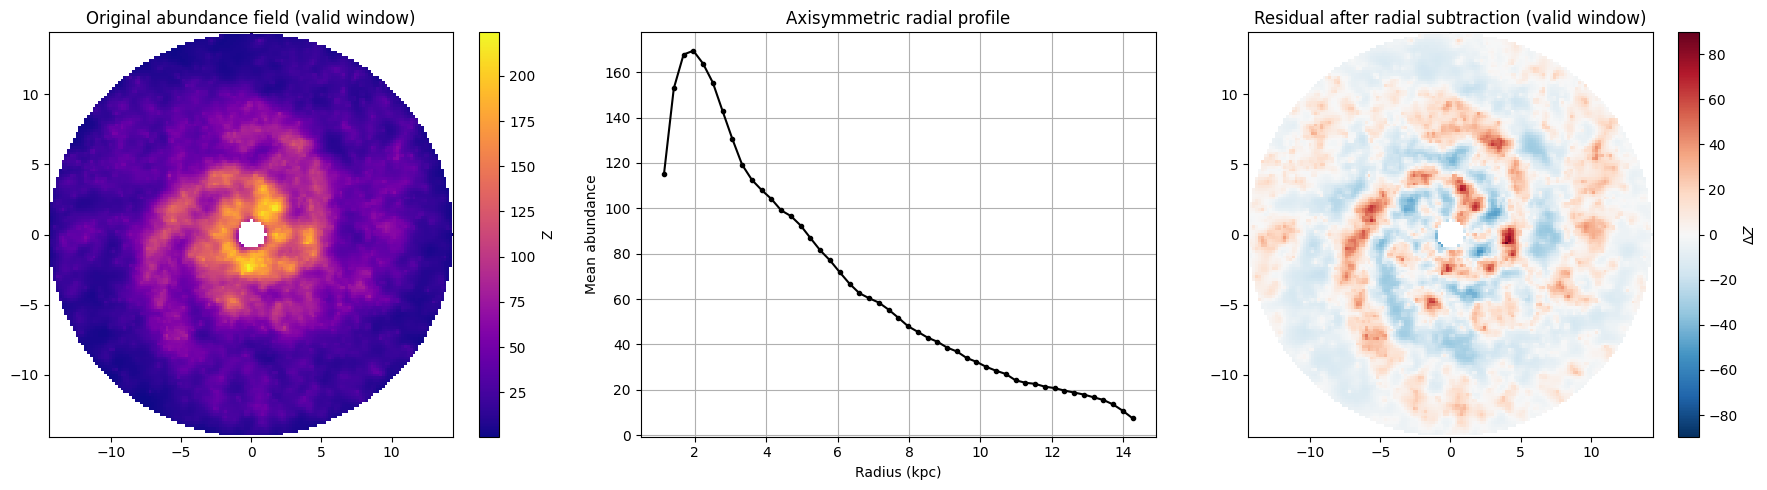

In [350]:
# %% Block 4: Subtraction of the radial gradient
R_grid = np.sqrt(X**2 + Y**2)
disk_mask = (R_grid >= R_in) & (R_grid <= R_out)
# A slightly eroded mask is used for continuous interpolation-based
# correlation measurements, so bilinear interpolation stencils do not mix in
# pixels from the excavated inner hole or exterior of the disc.
window_margin = np.sqrt(2.0) * dx
analysis_R_in = R_in + window_margin
analysis_R_out = R_out - window_margin
analysis_mask = (R_grid >= analysis_R_in) & (R_grid <= analysis_R_out)

R_bins = np.linspace(R_in, R_out, 50)
R_c = 0.5 * (R_bins[:-1] + R_bins[1:])

def subtract_radial_background(Z, make_plot=False):
    """Subtract the axisymmetric radial profile inside the valid annulus."""
    Z_rad = np.array([
        np.nanmean(np.where((R_grid >= rl) & (R_grid < rh) & disk_mask, Z, np.nan))
        for rl, rh in zip(R_bins[:-1], R_bins[1:])
    ])
    f_mean = interp1d(R_c, Z_rad, kind='linear',
                      bounds_error=False, fill_value=(Z_rad[0], Z_rad[-1]))
    Z_bg = np.full_like(Z, np.nan, dtype=float)
    Z_bg[disk_mask] = f_mean(R_grid[disk_mask])

    Z_res = np.full_like(Z, np.nan, dtype=float)
    Z_res[disk_mask] = Z[disk_mask] - Z_bg[disk_mask]
    Z_plot = np.where(disk_mask, Z, np.nan)
    Z_res_plot = np.where(disk_mask, Z_res, np.nan)
    Z_res_interp = np.where(np.isfinite(Z_res), Z_res, 0.0)

    if make_plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im1 = axes[0].pcolormesh(X, Y, Z_plot, cmap='plasma', shading='auto')
        plt.colorbar(im1, ax=axes[0], label='Z')
        axes[0].set_title('Original abundance field (valid window)')
        axes[0].set_xlim(-R_out, R_out)
        axes[0].set_ylim(-R_out, R_out)
        axes[0].set_aspect('equal')

        axes[1].plot(R_c, Z_rad, 'ko-', markersize=3)
        axes[1].set_xlabel('Radius (kpc)')
        axes[1].set_ylabel('Mean abundance')
        axes[1].set_title('Axisymmetric radial profile')
        axes[1].grid(True)

        vmax = np.nanmax(np.abs(Z_res_plot))
        im2 = axes[2].pcolormesh(X, Y, Z_res_plot, cmap='RdBu_r', shading='auto',
                                 vmin=-vmax, vmax=vmax)
        plt.colorbar(im2, ax=axes[2], label=r'$\Delta Z$')
        axes[2].set_title('Residual after radial subtraction (valid window)')
        axes[2].set_xlim(-R_out, R_out)
        axes[2].set_ylim(-R_out, R_out)
        axes[2].set_aspect('equal')

        plt.tight_layout()
        plt.show()

    return {
        'Z_rad': Z_rad,
        'Z_bg': Z_bg,
        'Z_res': Z_res,
        'Z_plot': Z_plot,
        'Z_res_plot': Z_res_plot,
        'Z_res_interp': Z_res_interp,
    }

first_residual = subtract_radial_background(Z, make_plot=True)
Z_rad = first_residual['Z_rad']
Z_bg = first_residual['Z_bg']
Z_res = first_residual['Z_res']
Z_plot = first_residual['Z_plot']
Z_res_plot = first_residual['Z_res_plot']
Z_res_interp = first_residual['Z_res_interp']


In [351]:
# %% Section 5: The two-point correlation function $\xi_2(\varpi_m, r)$ in the simulation
# Test midpoint radii are kept inside the eroded observing window.
radii_test = np.round(np.linspace(analysis_R_in + 0.5, analysis_R_out - 0.5, 6), 2)

# Pair separations are restricted to the physical outer radius of the disc.
max_pair_separation = R_out
r_bins = np.linspace(0.1, max_pair_separation, 30)
r_centers = 0.5*(r_bins[:-1] + r_bins[1:])
num_pairs = 50000

def measure_xi2_from_residual(Z_res_interp, rng):
    interp_Z = RegularGridInterpolator((grid_x, grid_y), Z_res_interp.T,
                                       bounds_error=False, fill_value=np.nan)
    corr = {}
    for varpi_m in radii_test:
        mid_phi = rng.uniform(0, 2*np.pi, num_pairs)
        sep_psi = rng.uniform(0, 2*np.pi, num_pairs)
        sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs)
        mid_x = varpi_m * np.cos(mid_phi)
        mid_y = varpi_m * np.sin(mid_phi)
        dx_pair = 0.5*sep_r*np.cos(sep_psi)
        dy_pair = 0.5*sep_r*np.sin(sep_psi)
        xm, ym = mid_x - dx_pair, mid_y - dy_pair
        xp, yp = mid_x + dx_pair, mid_y + dy_pair
        rm = np.hypot(xm,ym)
        rp = np.hypot(xp,yp)
        valid = (sep_r <= max_pair_separation) & (rm>=analysis_R_in) & (rm<=analysis_R_out) & (rp>=analysis_R_in) & (rp<=analysis_R_out)
        Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
        Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
        r_valid = sep_r[valid]
        corr_vals = np.full(len(r_centers), np.nan)
        for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
            mask = (r_valid>=rl) & (r_valid<rh) & np.isfinite(Zm) & np.isfinite(Zp)
            if np.sum(mask) > 10:
                # The radial profile has already been subtracted. Do not subtract
                # a fresh mean in each separation bin, because that would remove
                # part of the fixed spiral mean-field covariance C_M.
                z1 = Zm[mask]
                z2 = Zp[mask]
                denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
                corr_vals[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan
        corr[varpi_m] = corr_vals
    return corr

# Collect independent numerical realizations for error bands.
residual_fields = [Z_res_interp]
xi2_realizations = [measure_xi2_from_residual(Z_res_interp, rng)]
event_counts = [N_events]

for ireal in range(1, n_realizations):
    Z_i, N_i = generate_synthetic_galaxy(rng, return_events=False)
    res_i = subtract_radial_background(Z_i, make_plot=False)
    residual_fields.append(res_i['Z_res_interp'])
    xi2_realizations.append(measure_xi2_from_residual(res_i['Z_res_interp'], rng))
    event_counts.append(N_i)
    print(f"Completed realization {ireal+1}/{n_realizations}: N_events={N_i}")

sim_corr_mean = {
    varpi_m: np.nanmean(np.vstack([real[varpi_m] for real in xi2_realizations]), axis=0)
    for varpi_m in radii_test
}
sim_corr_std = {
    varpi_m: np.nanstd(np.vstack([real[varpi_m] for real in xi2_realizations]), axis=0, ddof=1)
    if n_realizations > 1 else np.zeros_like(sim_corr_mean[varpi_m])
    for varpi_m in radii_test
}
# Backward-compatible alias used by plotting cells.
sim_corr = sim_corr_mean
print(f"The numerical xi2 measurement is complete for {n_realizations} realizations.")


Completed realization 2/10: N_events=28012
Completed realization 3/10: N_events=28248
Completed realization 4/10: N_events=28596
Completed realization 5/10: N_events=27989
Completed realization 6/10: N_events=28374
Completed realization 7/10: N_events=28125
Completed realization 8/10: N_events=28128
Completed realization 9/10: N_events=28402
Completed realization 10/10: N_events=28070
The numerical xi2 measurement is complete for 10 realizations.


In [352]:
# %% Block 6: KTZ prediction
from functools import lru_cache

p0_val = x0**2
p_ast_val = x0**2 + 2*kappa*t_star
component_order = ['CP0', 'CPN', 'CM', 'CNP']
component_colors = {
    'CP0': '#4C78A8',
    'CPN': '#F58518',
    'CM': '#54A24B',
    'CNP': '#B279A2',
}
component_labels = {
    'CP0': r'$C_{\rm P,0}$',
    'CPN': r'$C_{\rm P,N}$',
    'CM': r'$C_{\rm M}$',
    'CNP': r'$C_{\rm NP}$',
}

@lru_cache(maxsize=None)
def I0(r):
    if r==0: return 0.5*np.log(p_ast_val/p0_val)
    # I0 = 1/2 [E1(r^2/4p_ast) - E1(r^2/4p0)] > 0.
    return 0.5*(exp1(r**2/(4*p_ast_val)) - exp1(r**2/(4*p0_val)))

@lru_cache(maxsize=None)
def InP(r, Qn):
    f = lambda p: 0.5/p * np.exp(-r**2/(4*p) - Qn**2*p/4)
    I, _ = quad(f, p0_val, p_ast_val, limit=100)
    return I

@lru_cache(maxsize=None)
def Tn(Qn):
    if Qn==0: return t_star
    return np.exp(-0.5*x0**2*Qn**2) * (1-np.exp(-kappa*t_star*Qn**2)) / (kappa*Qn**2)

# Thomas-process source clustering adds a non-Poisson covariance term.  We model
# the source pair correlation as Gaussian with correlation length
# l_src = sqrt(2)*cluster_radius, which corresponds to child offsets drawn with
# one-dimensional dispersion cluster_radius around each parent complex.
_cluster_quad_x, _cluster_quad_w = np.polynomial.legendre.leggauss(cluster_theory_nodes)
_cluster_t_nodes = 0.5*t_star*(_cluster_quad_x + 1.0)
_cluster_t_weights = 0.5*t_star*_cluster_quad_w
_cluster_p_nodes = x0**2 + 2*kappa*_cluster_t_nodes
_cluster_source_corr_len2 = 2.0*cluster_radius**2

@lru_cache(maxsize=None)
def I_cluster_np(r):
    if (not enable_source_clustering) or cluster_fraction <= 0 or cluster_radius <= 0:
        return 0.0
    denom = _cluster_source_corr_len2 + _cluster_p_nodes[:, None] + _cluster_p_nodes[None, :]
    weight = _cluster_t_weights[:, None] * _cluster_t_weights[None, :]
    integrand = (_cluster_source_corr_len2 / denom) * np.exp(-r**2/(2.0*denom))
    return float(np.sum(weight * integrand))

def CNP_prefactor(varpi_m):
    if (not enable_source_clustering) or cluster_fraction <= 0 or cluster_radius <= 0:
        return 0.0
    lam_local = lambda0_0 * np.exp(-varpi_m/h_R)
    lam_clustered = max(cluster_fraction * lam_local, 1.0e-30)
    # Thomas pair correlation at zero lag for the clustered component:
    # xi_src(0) approx mean_children/(4*pi*lambda_clustered*sigma_cl^2).
    xi0 = mean_children_per_cluster / (4*np.pi*lam_clustered*cluster_radius**2)
    # The total source covariance scales as lambda_total * cluster_fraction^2 * xi_src.
    return 4*np.pi*kappa*lam_local*(cluster_fraction**2)*xi0

def local_cov_component_parts(varpi_m, phi_m, r, psi):
    Theta_m = spiral_phase(varpi_m, phi_m)
    Q1 = k_perp(varpi_m)
    dPhi = (m_arms/np.tan(pitch_rad))/varpi_m
    grad_x = dPhi*np.cos(phi_m) + (m_arms/varpi_m)*np.sin(phi_m)
    grad_y = dPhi*np.sin(phi_m) - (m_arms/varpi_m)*np.cos(phi_m)
    grad = np.array([grad_x, grad_y])
    r_vec = r*np.array([np.cos(psi), np.sin(psi)])

    # Linearized endpoint phases: Theta_+ - Theta_- = grad(Theta) dot r_vec.
    dot = np.dot(grad, r_vec)
    Theta_minus = Theta_m - 0.5*dot
    Theta_plus  = Theta_m + 0.5*dot

    S1_m = np.cos(Theta_m)
    S1_mi = np.cos(Theta_minus)
    S1_pl = np.cos(Theta_plus)
    lam_local = lambda0_0 * np.exp(-varpi_m/h_R)
    R_val = 4*np.pi*kappa*lam_local*eta**2
    T1 = Tn(Q1)

    # Numerator covariance pieces, after extracting the common A_P factor.
    nums = {
        'CP0': I0(r),
        'CPN': eta*InP(r,Q1)*S1_m,
        'CM': R_val * T1**2 * S1_mi * S1_pl,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(r),
    }
    # Endpoint variance pieces. CNP uses the same local clustering approximation.
    vars_m_parts = {
        'CP0': I0(0),
        'CPN': eta*InP(0,Q1)*S1_mi,
        'CM': R_val*(T1*S1_mi)**2,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(0.0),
    }
    vars_p_parts = {
        'CP0': I0(0),
        'CPN': eta*InP(0,Q1)*S1_pl,
        'CM': R_val*(T1*S1_pl)**2,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(0.0),
    }
    return nums, vars_m_parts, vars_p_parts

def local_cov_components(varpi_m, phi_m, r, psi):
    nums, vars_m_parts, vars_p_parts = local_cov_component_parts(varpi_m, phi_m, r, psi)
    num = sum(nums.values())
    var_m = sum(vars_m_parts.values())
    var_p = sum(vars_p_parts.values())
    return num, var_m, var_p

def local_xi1(varpi_m, phi_m, r, psi):
    num, var_m, var_p = local_cov_components(varpi_m, phi_m, r, psi)
    if var_m<=0 or var_p<=0: return np.nan
    return num/np.sqrt(var_m*var_p)

def endpoint_window_ok(varpi_m, phi_m, r, psi):
    if r < 0 or r > max_pair_separation:
        return False
    mid_x = varpi_m*np.cos(phi_m)
    mid_y = varpi_m*np.sin(phi_m)
    hx = 0.5*r*np.cos(psi)
    hy = 0.5*r*np.sin(psi)
    rm = np.hypot(mid_x - hx, mid_y - hy)
    rp = np.hypot(mid_x + hx, mid_y + hy)
    return (analysis_R_in <= rm <= analysis_R_out) and (analysis_R_in <= rp <= analysis_R_out)

def _component_average_from_samples(sample_parts, estimator="pair_product"):
    if not sample_parts:
        return {name: np.nan for name in component_order}

    nums_by_component = {name: [] for name in component_order}
    vars_m_total, vars_p_total = [], []
    local_denoms = []
    for nums, vars_m_parts, vars_p_parts in sample_parts:
        var_m = sum(vars_m_parts.values())
        var_p = sum(vars_p_parts.values())
        if var_m <= 0 or var_p <= 0:
            continue
        for name in component_order:
            nums_by_component[name].append(nums[name])
        vars_m_total.append(var_m)
        vars_p_total.append(var_p)
        local_denoms.append(np.sqrt(var_m*var_p))

    if not vars_m_total:
        return {name: np.nan for name in component_order}

    if estimator == "mean_xi":
        local_denoms = np.asarray(local_denoms)
        return {
            name: np.mean(np.asarray(nums_by_component[name]) / local_denoms)
            for name in component_order
        }

    denom = np.sqrt(np.mean(vars_m_total)*np.mean(vars_p_total))
    return {
        name: np.mean(nums_by_component[name]) / denom
        for name in component_order
    }

def xi2_KTZ_components(varpi_m, r, Nphi=40, Npsi=40, estimator="pair_product"):
    phi_arr = np.linspace(0,2*np.pi,Nphi,endpoint=False)
    psi_arr = np.linspace(0,2*np.pi,Npsi,endpoint=False)
    sample_parts = []
    for phi in phi_arr:
        for psi in psi_arr:
            if endpoint_window_ok(varpi_m, phi, r, psi):
                sample_parts.append(local_cov_component_parts(varpi_m, phi, r, psi))
    return _component_average_from_samples(sample_parts, estimator=estimator)

def xi2_KTZ(varpi_m, r, Nphi=40, Npsi=40, estimator="pair_product"):
    """Windowed KTZ prediction.

    estimator="pair_product" matches the simulation estimator in Block 5:
    <Z_- Z_+>/sqrt(<Z_-^2><Z_+^2>) after radial subtraction.
    estimator="mean_xi" returns the paper definition, i.e. the windowed
    arithmetic mean of local xi_1 values.
    """
    comps = xi2_KTZ_components(varpi_m, r, Nphi=Nphi, Npsi=Npsi, estimator=estimator)
    return sum(comps.values())

def components_to_arrays(component_list):
    return {name: np.array([comp[name] for comp in component_list]) for name in component_order}


def plot_theory_component_stack(ax, r_plot, comp_plot, alpha=0.42):
    cumulative = np.zeros_like(r_plot, dtype=float)
    handles = []
    for name in component_order:
        vals = comp_plot[name]
        next_cumulative = cumulative + vals
        handle = ax.fill_between(
            r_plot, cumulative, next_cumulative,
            color=component_colors[name], alpha=alpha, linewidth=0,
            label=component_labels[name], zorder=1,
        )
        handles.append(handle)
        cumulative = next_cumulative
    return handles

wkb_components = {}
wkb_corr = {}
for varpi_m in radii_test:
    comp_list = [xi2_KTZ_components(varpi_m, r, estimator="pair_product") for r in r_centers]
    wkb_components[varpi_m] = components_to_arrays(comp_list)
    wkb_corr[varpi_m] = sum(wkb_components[varpi_m][name] for name in component_order)
print("Theoretical prediction with KTZ has been completed.")


Theoretical prediction with KTZ has been completed.


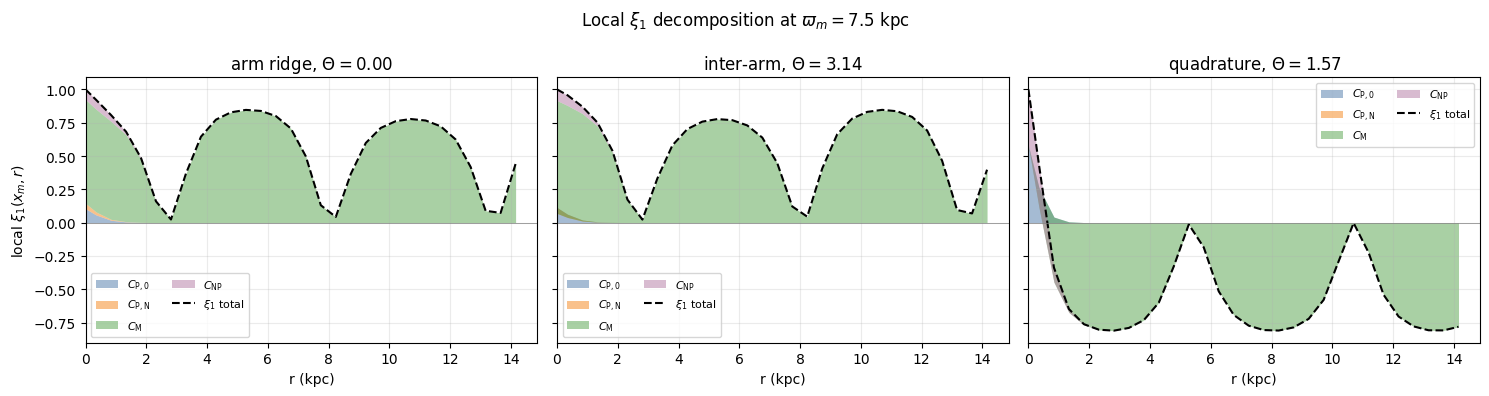

In [353]:
# %% Block 6b: Local xi1 diagnostic before annular averaging
# This diagnostic fixes the midpoint radius and spiral phase, so the signed CPN
# contribution is not averaged away over a full annulus. It is useful for
# checking the local theory before comparing xi2/xi3.

xi1_varpi_test = 7.5
xi1_phase_cases = {
    'arm ridge': 0.0,
    'inter-arm': np.pi,
    'quadrature': 0.5*np.pi,
}
xi1_psi_local = 0.0  # separation along the local arm-normal direction
xi1_r = r_centers

def phi_for_theta(varpi, theta_target):
    """Return a disc azimuth whose midpoint has the requested spiral phase."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return (Phi + Theta0 - theta_target) / m_arms

def xi1_components(varpi, theta_target, r, psi_local=0.0):
    phi_m = phi_for_theta(varpi, theta_target)
    dPhi = (m_arms/np.tan(pitch_rad))/varpi
    grad_x = dPhi*np.cos(phi_m) + (m_arms/varpi)*np.sin(phi_m)
    grad_y = dPhi*np.sin(phi_m) - (m_arms/varpi)*np.cos(phi_m)
    grad_angle = np.arctan2(grad_y, grad_x)
    psi_global = grad_angle + psi_local
    nums, var_m_parts, var_p_parts = local_cov_component_parts(varpi, phi_m, r, psi_global)
    var_m = sum(var_m_parts.values())
    var_p = sum(var_p_parts.values())
    if var_m <= 0 or var_p <= 0:
        return {name: np.nan for name in component_order}
    denom = np.sqrt(var_m*var_p)
    return {name: nums[name]/denom for name in component_order}

fig, axes = plt.subplots(1, len(xi1_phase_cases), figsize=(15, 4), sharey=True)
if len(xi1_phase_cases) == 1:
    axes = [axes]

for ax, (label, theta_target) in zip(axes, xi1_phase_cases.items()):
    comp_list = [xi1_components(xi1_varpi_test, theta_target, r, xi1_psi_local) for r in xi1_r]
    comp_arrays = components_to_arrays(comp_list)
    comp0 = xi1_components(xi1_varpi_test, theta_target, 0.0, xi1_psi_local)
    comp_plot = {
        name: np.concatenate([[comp0[name]], comp_arrays[name]])
        for name in component_order
    }
    r_plot = np.concatenate([[0.0], xi1_r])
    xi1_total = sum(comp_plot[name] for name in component_order)

    plot_theory_component_stack(ax, r_plot, comp_plot, alpha=0.5)
    ax.plot(r_plot, xi1_total, 'k--', lw=1.5, label=r'$\xi_1$ total')
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(fr'{label}, $\Theta={theta_target:.2f}$')
    ax.set_xlabel('r (kpc)')
    ax.set_xlim(left=0)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel(r'local $\xi_1(x_m, r)$')
fig.suptitle(fr'Local $\xi_1$ decomposition at $\varpi_m={xi1_varpi_test}$ kpc')
plt.tight_layout()
plt.show()


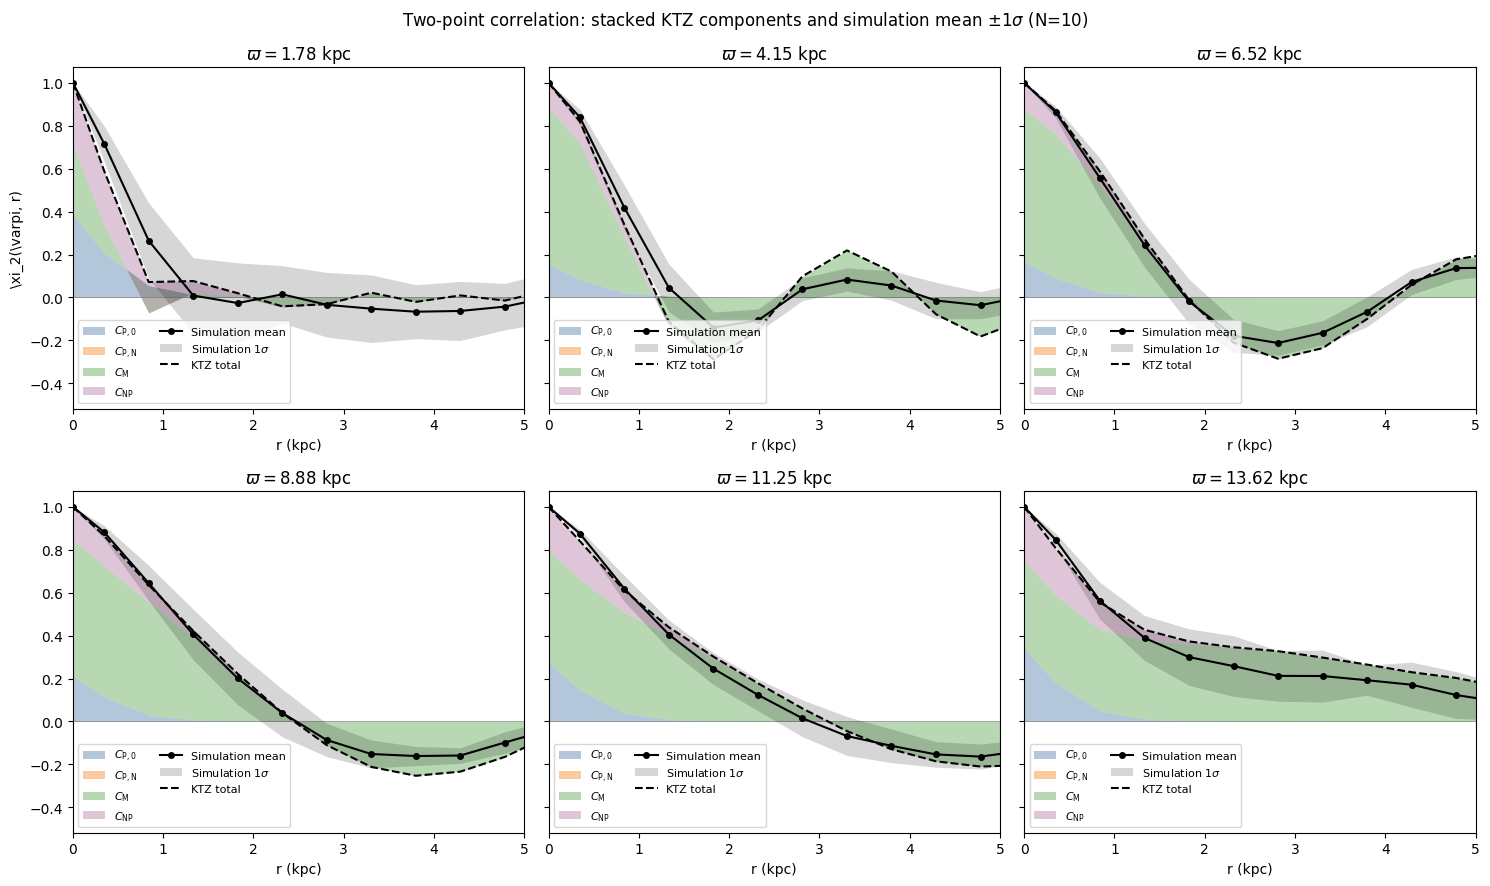

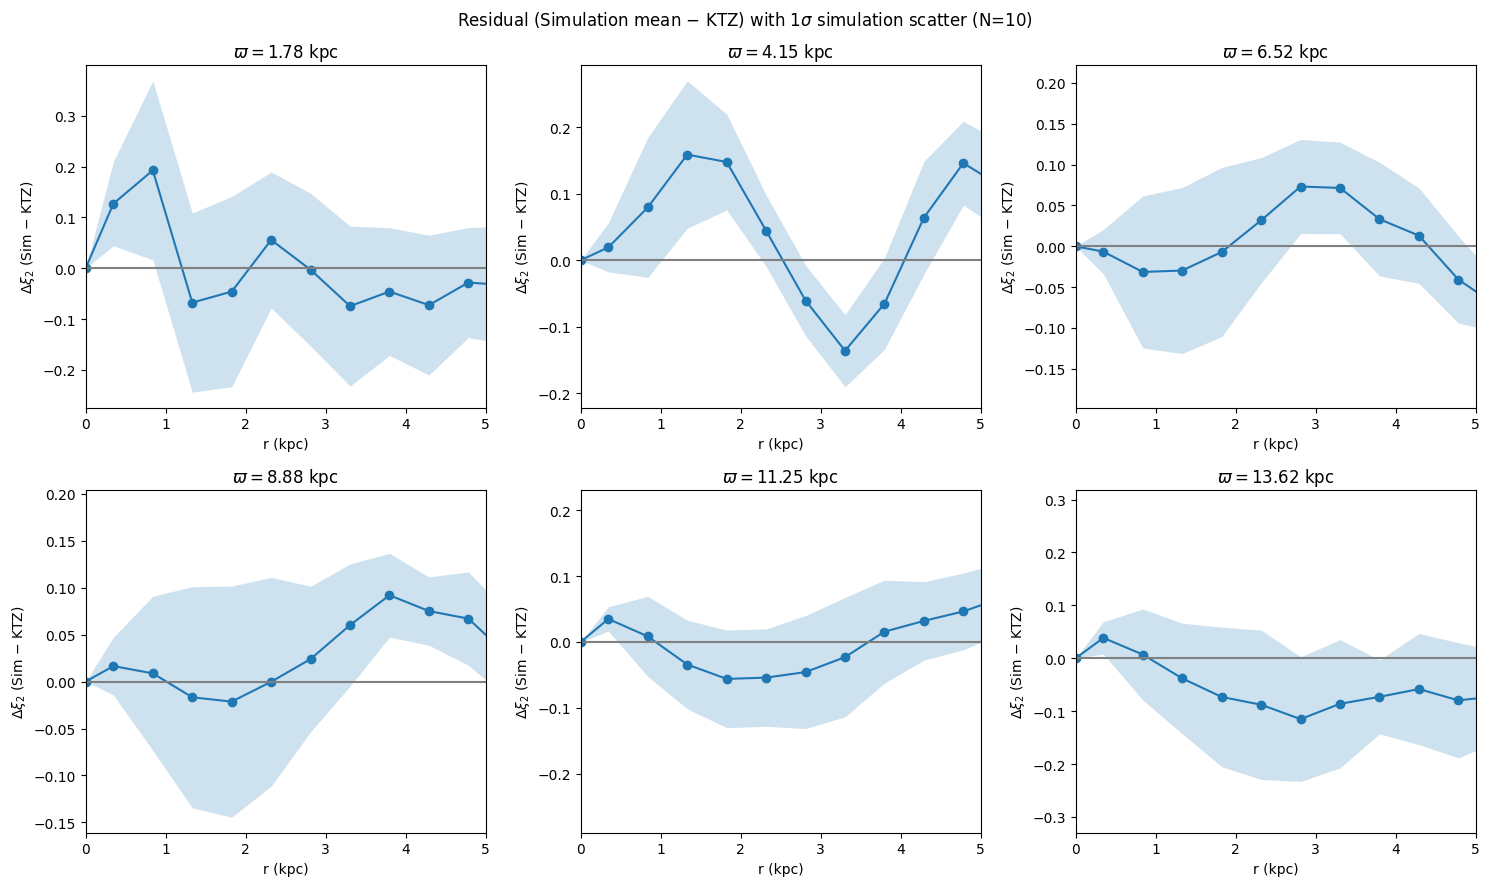

In [354]:
# %% Block 7a: Comparison of correlation functions
correlation_plot_rmax = 5.0
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, varpi_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    sim_mean = np.concatenate([[1.0], sim_corr_mean[varpi_m]])
    sim_std = np.concatenate([[0.0], sim_corr_std[varpi_m]])
    comp0 = xi2_KTZ_components(varpi_m, 0.0, estimator="pair_product")
    comp_plot = {
        name: np.concatenate([[comp0[name]], wkb_components[varpi_m][name]])
        for name in component_order
    }
    wkb_plot = sum(comp_plot[name] for name in component_order)

    plot_theory_component_stack(ax, r_plot, comp_plot)
    ax.plot(r_plot, sim_mean, 'o-', color='black', ms=4, label='Simulation mean', zorder=4)
    ax.fill_between(r_plot, sim_mean-sim_std, sim_mean+sim_std,
                    color='black', alpha=0.16, linewidth=0,
                    label=r'Simulation $1\sigma$', zorder=3)
    ax.plot(r_plot, wkb_plot, 'k--', lw=1.5, label='KTZ total', zorder=5)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(fr'$\varpi = {varpi_m}$ kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_xlim(0, correlation_plot_rmax)
    ax.legend(loc='lower left', fontsize=8, ncol=2)

axes[0].set_ylabel(r'\xi_2(\varpi, r)')
fig.suptitle(fr'Two-point correlation: stacked KTZ components and simulation mean $\pm 1\sigma$ (N={n_realizations})')
plt.tight_layout()
plt.show()

# %% Block 7b: Residual
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, varpi_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    comp0 = xi2_KTZ_components(varpi_m, 0.0, estimator="pair_product")
    wkb_plot = sum(
        np.concatenate([[comp0[name]], wkb_components[varpi_m][name]])
        for name in component_order
    )
    # At zero separation both simulation and theory are normalized to xi=1,
    # so the residual must be exactly zero.
    diff = np.concatenate([[1.0], sim_corr_mean[varpi_m]]) - wkb_plot
    diff[0] = 0.0
    sim_std = np.concatenate([[0.0], sim_corr_std[varpi_m]])

    ax.plot(r_plot, diff, 'o-')
    ax.fill_between(r_plot, diff-sim_std, diff+sim_std,
                    color='C0', alpha=0.22, linewidth=0)
    ax.axhline(0, color='grey')
    ax.set_title(fr'$\varpi = {varpi_m}$ kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_ylabel(r'$\Delta\xi_2$ (Sim $-$ KTZ)')
    ax.set_xlim(0, correlation_plot_rmax)

fig.suptitle(fr'Residual (Simulation mean $-$ KTZ) with $1\sigma$ simulation scatter (N={n_realizations})')
plt.tight_layout()
plt.show()


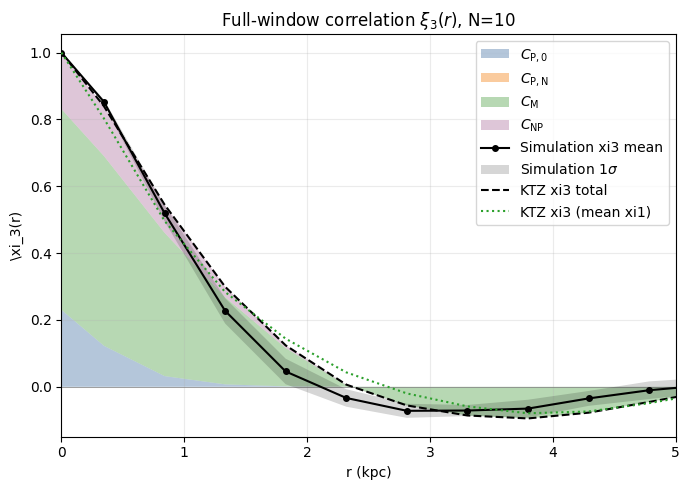

In [355]:
# %% Block 8: xi3(r) over the full observing window
# xi3 averages over all valid midpoint radii and separation directions.
# The simulation and KTZ curves both use the pair-product estimator so that
# they are directly comparable after radial-background subtraction.

num_pairs_xi3 = 150000

def measure_xi3_from_residual(Z_res_interp, rng):
    interp_Z = RegularGridInterpolator((grid_x, grid_y), Z_res_interp.T,
                                       bounds_error=False, fill_value=np.nan)
    mid_R = np.sqrt(rng.uniform(analysis_R_in**2, analysis_R_out**2, num_pairs_xi3))
    mid_phi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
    sep_psi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
    sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs_xi3)

    mid_x = mid_R*np.cos(mid_phi)
    mid_y = mid_R*np.sin(mid_phi)
    hx = 0.5*sep_r*np.cos(sep_psi)
    hy = 0.5*sep_r*np.sin(sep_psi)
    xm, ym = mid_x - hx, mid_y - hy
    xp, yp = mid_x + hx, mid_y + hy
    valid = (
        (sep_r <= max_pair_separation) &
        (np.hypot(xm,ym) >= analysis_R_in) & (np.hypot(xm,ym) <= analysis_R_out) &
        (np.hypot(xp,yp) >= analysis_R_in) & (np.hypot(xp,yp) <= analysis_R_out)
    )
    Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
    Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
    r_valid = sep_r[valid]

    xi3_vals = np.full(len(r_centers), np.nan)
    for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mask = (r_valid >= rl) & (r_valid < rh) & np.isfinite(Zm) & np.isfinite(Zp)
        if np.sum(mask) > 10:
            z1 = Zm[mask]
            z2 = Zp[mask]
            denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
            xi3_vals[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan
    return xi3_vals

xi3_realizations = [measure_xi3_from_residual(field, rng) for field in residual_fields]
xi3_stack = np.vstack(xi3_realizations)
xi3_sim_mean = np.nanmean(xi3_stack, axis=0)
xi3_sim_std = np.nanstd(xi3_stack, axis=0, ddof=1) if n_realizations > 1 else np.zeros_like(xi3_sim_mean)
# Backward-compatible alias.
xi3_sim = xi3_sim_mean

def xi3_KTZ_components(r, Nvarpi=30, Nphi=20, Npsi=20, estimator="pair_product"):
    # Equal spacing in R^2 gives equal-area annular samples for the midpoint.
    rho2_edges = np.linspace(analysis_R_in**2, analysis_R_out**2, Nvarpi+1)
    varpi_arr = np.sqrt(0.5*(rho2_edges[:-1] + rho2_edges[1:]))
    phi_arr = np.linspace(0, 2*np.pi, Nphi, endpoint=False)
    psi_arr = np.linspace(0, 2*np.pi, Npsi, endpoint=False)
    sample_parts = []
    for varpi in varpi_arr:
        for phi in phi_arr:
            for psi in psi_arr:
                if endpoint_window_ok(varpi, phi, r, psi):
                    sample_parts.append(local_cov_component_parts(varpi, phi, r, psi))
    return _component_average_from_samples(sample_parts, estimator=estimator)

def xi3_KTZ(r, Nvarpi=30, Nphi=20, Npsi=20, estimator="pair_product"):
    comps = xi3_KTZ_components(r, Nvarpi=Nvarpi, Nphi=Nphi, Npsi=Npsi, estimator=estimator)
    return sum(comps.values())

xi3_component_list = [xi3_KTZ_components(r, estimator="pair_product") for r in r_centers]
xi3_ktz_components = components_to_arrays(xi3_component_list)
xi3_ktz = sum(xi3_ktz_components[name] for name in component_order)
xi3_ktz_meanxi = np.array([xi3_KTZ(r, estimator="mean_xi") for r in r_centers])

fig, ax = plt.subplots(figsize=(7, 5))
r_plot = np.concatenate([[0.0], r_centers])
sim_plot = np.concatenate([[1.0], xi3_sim_mean])
sim_std = np.concatenate([[0.0], xi3_sim_std])
ktz_plot = np.concatenate([[1.0], xi3_ktz])
ktz_meanxi_plot = np.concatenate([[1.0], xi3_ktz_meanxi])

xi3_comp0 = xi3_KTZ_components(0.0, estimator="pair_product")
xi3_comp_plot = {
    name: np.concatenate([[xi3_comp0[name]], xi3_ktz_components[name]])
    for name in component_order
}
plot_theory_component_stack(ax, r_plot, xi3_comp_plot)
ktz_plot = sum(xi3_comp_plot[name] for name in component_order)

ax.plot(r_plot, sim_plot, 'o-', color='black', ms=4, label='Simulation xi3 mean', zorder=4)
ax.fill_between(r_plot, sim_plot-sim_std, sim_plot+sim_std,
                color='black', alpha=0.16, linewidth=0,
                label=r'Simulation $1\sigma$', zorder=3)
ax.plot(r_plot, ktz_plot, 'k--', lw=1.5, label='KTZ xi3 total', zorder=5)
ax.plot(r_plot, ktz_meanxi_plot, ':', color='C2', label='KTZ xi3 (mean xi1)', zorder=5)
ax.axhline(0, color='grey', lw=0.5)
ax.set_xlabel('r (kpc)')
ax.set_ylabel(r'\xi_3(r)')
ax.set_xlim(0, correlation_plot_rmax)
ax.set_title(fr'Full-window correlation $\xi_3(r)$, N={n_realizations}')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
